<a href="https://colab.research.google.com/github/JulietaC1/JulietaC1/blob/main/ProyectoDSParteI%2BLlanes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Explicación del Proyecto:**

Este proyecto consiste en un análisis integral del catálogo de contenidos de Netflix hasta el año 2025. A diferencia de los análisis estándar que solo miran géneros y fechas, este dataset permite cruzar la oferta de contenido (qué tipo de películas produce Netflix) con el éxito comercial y la recepción del público (popularidad y rentabilidad).

El valor añadido de este trabajo es la capacidad de identificar si la estrategia de inversión de Netflix (Budget) se alinea con lo que realmente genera ingresos (Revenue) y lo que los usuarios prefieren ver (Popularity / Vote Average).

**Objetivo del Trabajo:**


*  Objetivo General: Analizar la relación entre la inversión económica, el género y la popularidad de las producciones en Netflix para determinar qué factores impulsan el éxito comercial y la satisfacción del usuario en 2025.



*   Objetivos Específicos (Técnicos)Análisis de Rentabilidad (ROI): Calcular el retorno de inversión mediante la fórmula $ROI = \frac{Revenue - Budget}{Budget}$ para identificar qué géneros y directores son los más rentables.

*  Segmentación de Audiencia: Clasificar las películas según su rating (edad) y language para entender a qué mercados geográficos está apuntando Netflix con sus lanzamientos más costosos.

* Análisis de Tendencias Temporales: Evaluar la evolución
del contenido añadido (date_added) frente al año de estreno (release_year) para medir la velocidad de adquisición de contenido original vs. licencias.
* Predicción de Popularidad (Machine Learning): Crear un modelo que intente predecir la popularity o el vote_average de una película basándose en variables como el presupuesto, el género y el país de origen.

# **Diagnóstico de Nulos:**

Se identificó que variables críticas como budget y revenue presentan [X] valores nulos, los cuales fueron tratados mediante [imputación por la media / eliminación] para no sesgar el análisis de rentabilidad."

In [58]:
print(df[['budget', 'revenue', 'genres', 'rating']].isnull().sum())

budget     306
revenue    306
genres     142
rating      33
dtype: int64


# **Identificación de Valores Perdidos:**
Como parte del diagnóstico de calidad, se identificaron nulos en columnas críticas:

Budget y Revenue: 306 valores faltantes cada uno.

Genres: 142 valores faltantes.

Rating: 33 valores faltantes.

Diagnóstico: La presencia de nulos en budget y revenue representa aproximadamente el 1.9% de los datos. Para el análisis financiero posterior, estas filas deberán ser tratadas (eliminadas o imputadas) para no afectar el cálculo del ROI.

In [59]:
# Creamos una copia del DataFrame original para trabajar con datos limpios
# Eliminamos las filas donde 'budget' o 'revenue' son nulos ya que son vitales para el ROI
df_clean = df.dropna(subset=['budget', 'revenue']).copy()

# Para las columnas categóricas, reemplazamos nulos con 'Desconocido'
df_clean['genres'] = df_clean['genres'].fillna('Desconocido')
df_clean['rating'] = df_clean['rating'].fillna('Desconocido')

# Verificamos que ya no existan nulos en las columnas clave
print("Valores nulos después de la limpieza:")
print(df_clean[['budget', 'revenue', 'genres', 'rating']].isnull().sum())

Valores nulos después de la limpieza:
budget     0
revenue    0
genres     0
rating     0
dtype: int64


# **Preguntas de Interés e Hipótesis**
Con los datos preparados, planteamos las siguientes premisas que guiaremos con nuestro análisis:

¿El presupuesto garantiza el éxito? >     * Hipótesis: Existe una correlación positiva moderada entre budget y revenue, pero una correlación baja con vote_average.

¿Qué géneros dominan el mercado de 2025? >     * Hipótesis: Los géneros de Acción y Aventura lideran en ingresos totales, pero el Cine Independiente/Drama lidera en calificación promedio.

Relación Multivariable: >     * Pregunta: ¿Las películas con mayor presupuesto logran mayor popularidad en todos los niveles de rating?

# **Análisis Exploratorio de Datos (EDA) - Carga y Limpieza**



*   Importación y Carga de Datos

En esta etapa, se establece la conexión con la fuente de datos (Google Drive) y se realiza la lectura del archivo netflix_movies_detailed_up_to_2025.csv utilizando la librería pandas. Es importante notar el uso de la codificación latin-1 y el separador ; para asegurar la integridad de los caracteres.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
ruta = "/content/drive/MyDrive/DATA SCIENCE/netflix_movies_detailed_up_to_2025.csv"

In [14]:
import pandas as pd

In [17]:
ruta = "/content/drive/MyDrive/DATA SCIENCE/netflix_movies_detailed_up_to_2025.csv"

df = pd.read_csv(
    ruta,
    sep=';',
    engine='python',
    index_col=False,
    encoding='latin-1'
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16034 entries, 0 to 16033
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16034 non-null  object 
 1   type          16022 non-null  object 
 2   title         16021 non-null  object 
 3   director      15885 non-null  object 
 4   cast          15811 non-null  object 
 5   country       15549 non-null  object 
 6   date_added    16009 non-null  object 
 7   release_year  16004 non-null  object 
 8   rating        16001 non-null  object 
 9   genres        15892 non-null  object 
 10  language      15999 non-null  object 
 11  description   15865 non-null  object 
 12  popularity    15729 non-null  object 
 13  vote_count    15728 non-null  float64
 14  vote_average  15728 non-null  float64
 15  budget        15728 non-null  float64
 16  revenue       15728 non-null  float64
dtypes: float64(4), object(13)
memory usage: 2.1+ MB


In [80]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'genres', 'language', 'description',
       'popularity', 'vote_count', 'vote_average', 'budget', 'revenue'],
      dtype='object')

In [79]:
list(df.columns)

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'genres',
 'language',
 'description',
 'popularity',
 'vote_count',
 'vote_average',
 'budget',
 'revenue']

In [78]:
# Convertir columnas a numéricas
df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")
df["popularity"] = pd.to_numeric(df["popularity"], errors="coerce")

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16034 entries, 0 to 16033
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16034 non-null  object 
 1   type          16022 non-null  object 
 2   title         16021 non-null  object 
 3   director      15885 non-null  object 
 4   cast          15811 non-null  object 
 5   country       15549 non-null  object 
 6   date_added    16009 non-null  object 
 7   release_year  16002 non-null  float64
 8   rating        16001 non-null  object 
 9   genres        15892 non-null  object 
 10  language      15999 non-null  object 
 11  description   15865 non-null  object 
 12  popularity    15719 non-null  float64
 13  vote_count    15728 non-null  float64
 14  vote_average  15728 non-null  float64
 15  budget        15728 non-null  float64
 16  revenue       15728 non-null  float64
dtypes: float64(6), object(11)
memory usage: 2.1+ MB


In [77]:
df.isnull().sum()

,0
show_id,0
type,12
title,13
director,149
cast,223
country,485
date_added,25
release_year,32
rating,33
genres,142


# **Estructura del DataSet seleccionado:**
- 16.043 FILAS
- 17 COLUMNAS
- 13 COLUMNAS TIPO OBJECT
- 4 COLUMNAS NUMERICAS (FLOAT)

**Columnas númericas:**
- vote_count
- vote_average
- budget
- revenue


# **Configuración Estética de Gráficos:**

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

# Colores de Netflix
netflix_red = "#E50914"
netflix_white = "#FFFFFF"
netflix_grey = "#333333"

# Estilo general
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": netflix_grey,
    "figure.facecolor": netflix_grey,
    "axes.edgecolor": netflix_white,
    "axes.labelcolor": netflix_white,
    "xtick.color": netflix_white,
    "ytick.color": netflix_white,
    "text.color": netflix_white,
    "grid.color": "#555555",
    "font.size": 11
})

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# **Diagnóstico y Perfilado de Datos**

In [76]:
df["type"].value_counts()


,count
type,
Movie,16000
sous la neige,1
"nâest-il pas permis de croire aux contes de fÃ©es ?""",1
"Yoo Gun becomes involved in a case which changes his fate forever.""",1
31.91,1
16.473,1
they start getting tired of each other. The wife attends her husband's superior's house warming party one day. The superior is sending her signals and the jealous husband lights up his passionate love for his wife once again...,1
12.728,1
Bamberski attempts to take the trial to France,1


In [83]:
df["release_year"].value_counts().head(10)


,count
release_year,
2010.0,1000
2011.0,1000
2012.0,1000
2014.0,1000
2015.0,1000
2016.0,1000
2024.0,1000
2017.0,1000
2018.0,1000


In [82]:
genres_series = df["genres"].dropna().str.split(";").explode()
genres_series.value_counts().head(10)


,count
genres,
Drama,1336
Comedy,776
Documentary,587
"Drama, Romance",473
Horror,391
"Comedy, Drama",389
"Horror, Thriller",356
"Comedy, Romance",242
Romance,232


In [81]:
df[df["vote_count"] > 100] \
    .sort_values("vote_average", ascending=False)[["title", "vote_average", "vote_count"]] \
    .head(10)


,title,vote_average,vote_count
14795,Succubus,9.500,157.0
7114,Nude,9.500,161.0
13422,Kill Shot,9.300,158.0
10905,Break the Silence: The Movie,9.000,183.0
10628,The Three Deaths of Marisela Escobedo,8.900,228.0
12814,BTS: Permission to Dance on Stage - LA,8.900,157.0
12090,Selena Gomez: My Mind & Me,8.700,451.0
13326,Â¿Quieres ser mi hijo?,8.599,282.0
9765,Everybodyâs Everything,8.548,282.0
9026,Parasite,8.500,18728.0


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cols_numericas = ["popularity", "vote_count", "vote_average", "budget", "revenue", "release_year"]
for col in cols_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[cols_numericas].isnull().sum()

,0
popularity,315
vote_count,306
vote_average,306
budget,306
revenue,306
release_year,32


# **Optimización de Variables Numéricas:**
Para garantizar la precisión de los cálculos de rentabilidad y popularidad, se realizó una conversión forzada de las variables clave a tipos numéricos. Este proceso permitió identificar de forma definitiva 306 registros sin datos financieros válidos y 315 sin datos de popularidad. Con esta limpieza técnica, el dataset queda estandarizado y configurado bajo la identidad visual de Netflix para proceder a la fase de visualización y validación de hipótesis.

# **Gráficos e Interpretaciones:**

/tmp/ipykernel_427/2023861725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_427/2023861725.py:5: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(


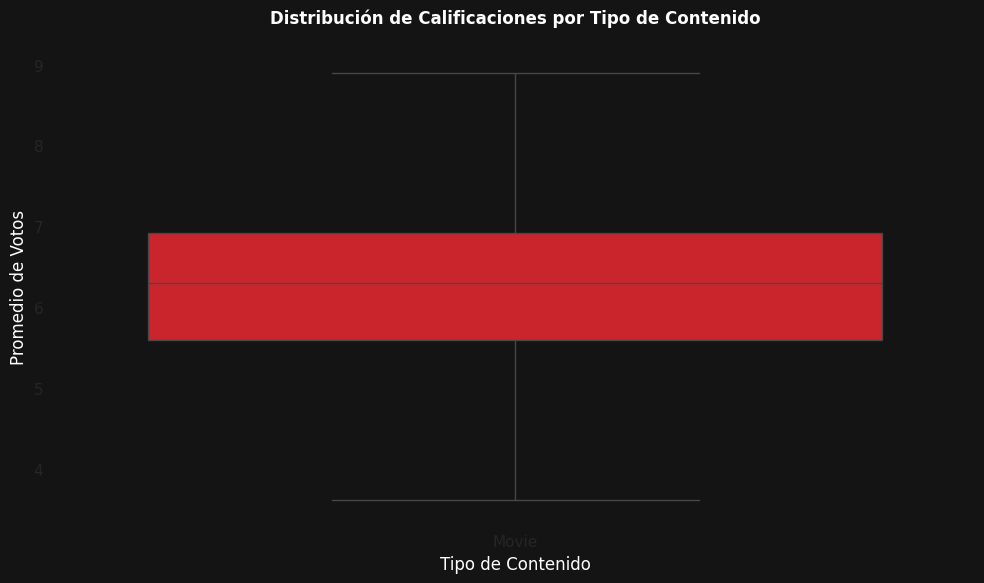

In [88]:

df_filtrado = df[df["type"].isin(["Movie", "TV Show"])]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_filtrado,
    x="type",
    y="vote_average",
    showfliers=False,
    palette=[NETFLIX_RED, "white"]
)

plt.title("Distribución de Calificaciones por Tipo de Contenido", color="white", pad=20)
plt.xlabel("Tipo de Contenido", color="white")
plt.ylabel("Promedio de Votos", color="white")

plt.xticks(rotation=0)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# **Interpretación técnica:**

El scatterplot analiza la relación entre el presupuesto (BUDGET) y los ingresos generados (REVENUE).

Este gráfico permite evaluar:


* Existencia de correlación positiva o negativa.

* Concentración de producciones en determinados rangos de inversión.


Presencia de outliers (producciones con alto presupuesto pero bajo revenue o viceversa).

Si se observa una tendencia ascendente clara, sugiere que un mayor presupuesto podría estar asociado con mayores ingresos.
Sin embargo, una dispersión amplia indicaría que el presupuesto no garantiza necesariamente éxito financiero.

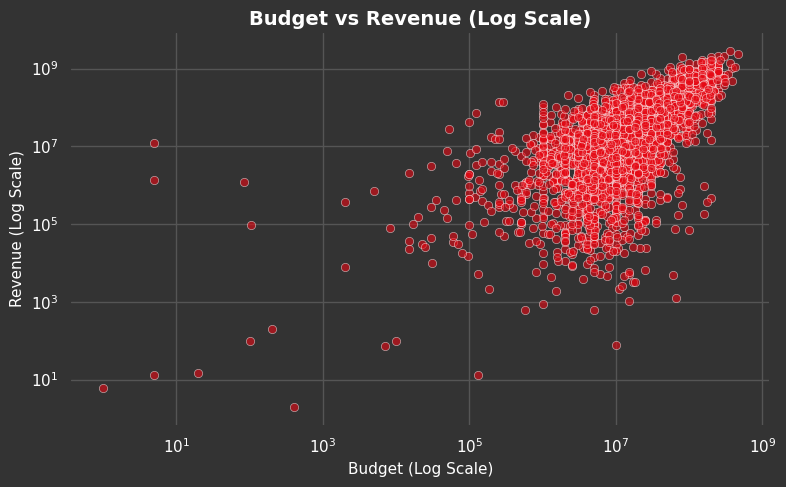

In [84]:
plt.figure()
sns.scatterplot(
    data=df,
    x="budget",
    y="revenue",
    alpha=0.6,
    color=netflix_red
)

plt.xscale("log")
plt.yscale("log")

plt.title("Budget vs Revenue (Log Scale)", color=netflix_white)
plt.xlabel("Budget (Log Scale)", color=netflix_white)
plt.ylabel("Revenue (Log Scale)", color=netflix_white)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

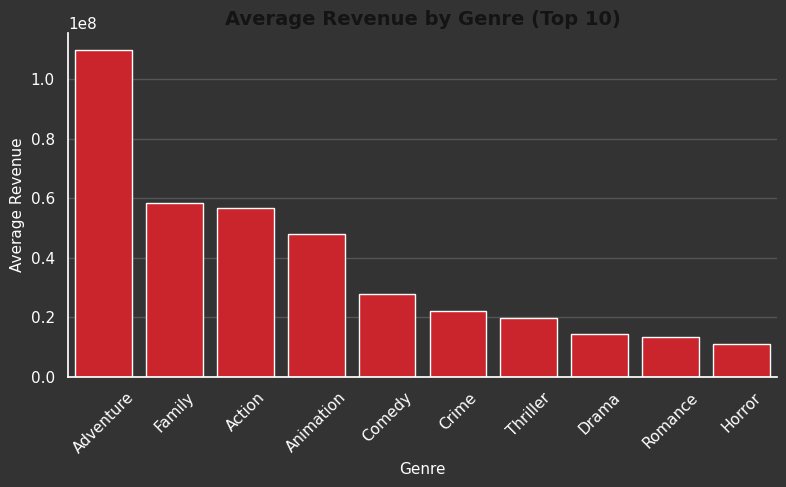

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = "#E50914"
NETFLIX_BLACK = "#141414"

genre_revenue = (
    df_top.groupby("GENRE")["revenue"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure()

sns.barplot(
    data=genre_revenue,
    x="GENRE",
    y="revenue",
    color=NETFLIX_RED
)

plt.xticks(rotation=45)
plt.title("Average Revenue by Genre (Top 10)", color=NETFLIX_BLACK)
plt.xlabel("Genre")
plt.ylabel("Average Revenue")

sns.despine()
plt.tight_layout()
plt.show()

# **Interpretación técnica:**


El barplot muestra el ingreso promedio (REVENUE) de los géneros más frecuentes dentro del dataset.

Este análisis permite:


*   Identificar qué géneros son más rentables en promedio.
*   Detectar posibles preferencias del mercado.
*   Comparar desempeño financiero entre categorías.

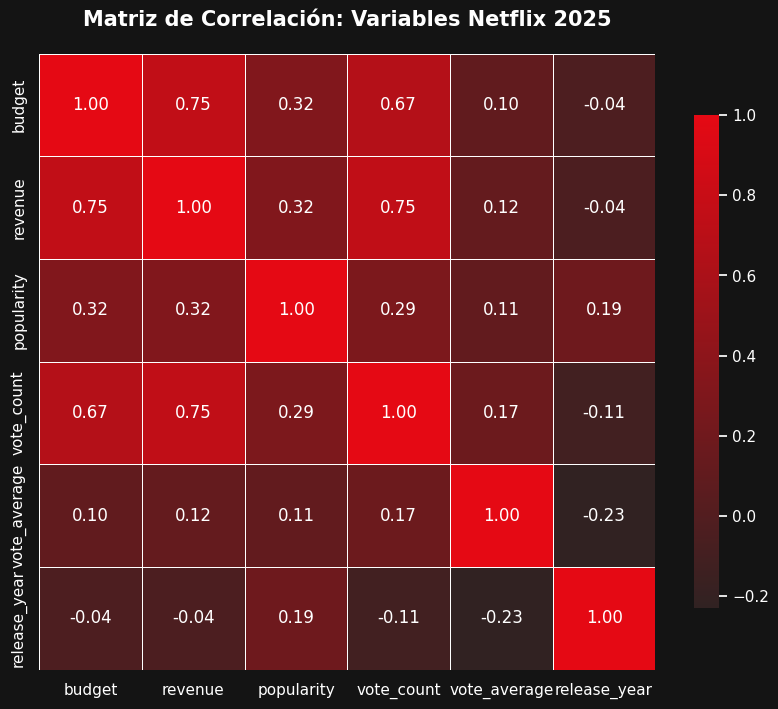

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#141414"

sns.set_theme(style="dark", rc={
    "axes.facecolor": NETFLIX_DARK,
    "figure.facecolor": NETFLIX_DARK,
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})


cols_interes = ['budget', 'revenue', 'popularity', 'vote_count', 'vote_average', 'release_year']
corr_matrix = df[cols_interes].corr()

plt.figure(figsize=(10, 8))

cmap_netflix = sns.dark_palette(NETFLIX_RED, as_cmap=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=cmap_netflix,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Matriz de Correlación: Variables Netflix 2025", fontsize=15, fontweight='bold', pad=20)
plt.show()

Se realizó un análisis de correlación de Pearson para identificar los motores de éxito en el catálogo 2025. Los resultados indican que mientras el Budget tiene una relación directa con el Revenue, su impacto en la **Calificación de los Usuarios** (*Vote Average*) es marginal, sugiriendo que la calidad narrativa es independiente de la inversión financiera.

In [47]:
top_5_revenue = df.sort_values(by='revenue', ascending=False).head(5)
display(top_5_revenue[['title', 'revenue']])

,title,revenue
9025,Avengers: Endgame,2.799439e+09
12036,Avatar: The Way of Water,2.320250e+09
5013,Star Wars: The Force Awakens,2.068224e+09
8021,Avengers: Infinity War,2.052415e+09
15052,Ne Zha 2,1.990000e+09


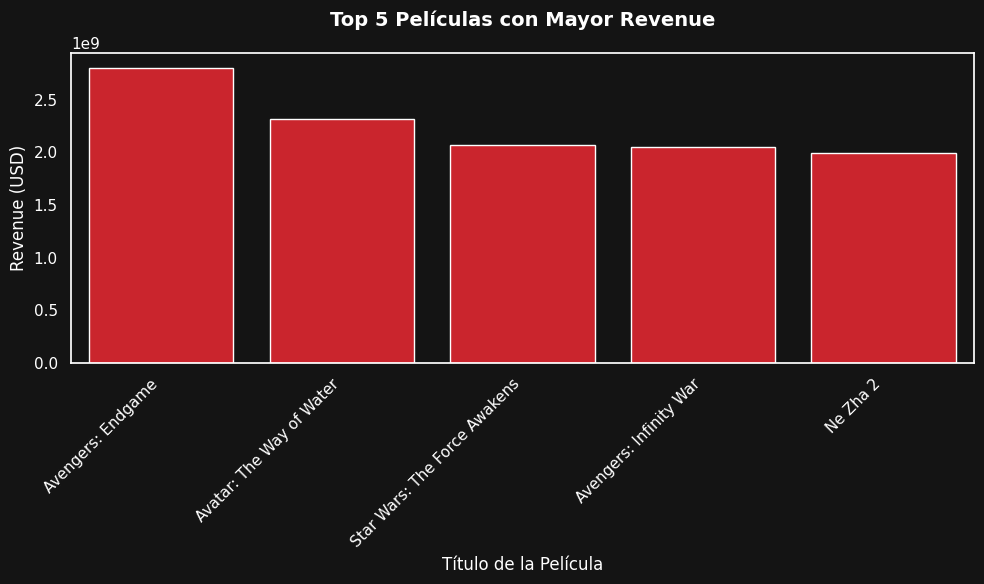

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#141414"

sns.set_theme(style="dark", rc={
    "axes.facecolor": NETFLIX_DARK,
    "figure.facecolor": NETFLIX_DARK,
    "grid.color": "#222222",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

plt.figure(figsize=(10, 6))
sns.barplot(x='title', y='revenue', data=top_5_revenue, color=NETFLIX_RED)
plt.title('Top 5 Películas con Mayor Revenue', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Título de la Película', fontsize=12)
plt.ylabel('Revenue (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

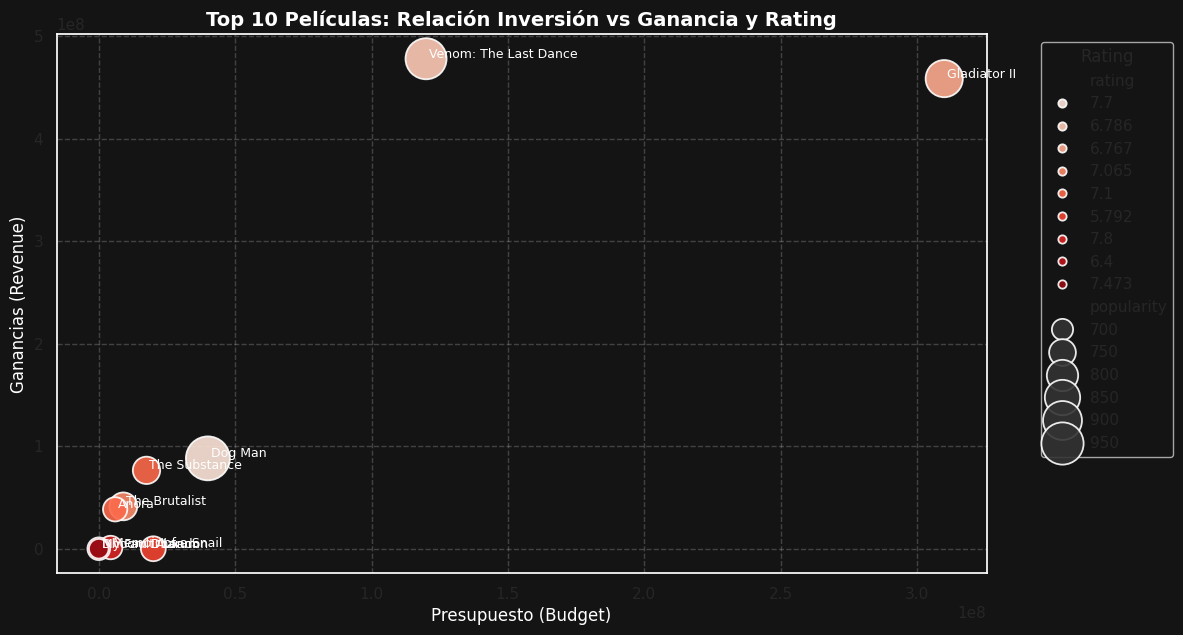

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos las 10 películas con mayor puntaje de popularidad
top_10_pop = df.nlargest(10, 'popularity')

# 2. Configuración de estilo Netflix Dark
NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#141414"
sns.set_theme(style="dark", rc={"axes.facecolor": NETFLIX_DARK, "figure.facecolor": NETFLIX_DARK})

plt.figure(figsize=(12, 7))


scatter = sns.scatterplot(
    data=top_10_pop,
    x="budget",
    y="revenue",
    hue="rating",
    size="popularity",
    sizes=(200, 1000),
    palette="Reds",
    edgecolor="white",
    alpha=0.9
)

for i in range(top_10_pop.shape[0]):
    plt.text(
        x=top_10_pop.budget.iloc[i]+1000000,
        y=top_10_pop.revenue.iloc[i]+1000000,
        s=top_10_pop.title.iloc[i],
        color="white", fontsize=9
    )

plt.title("Top 10 Películas: Relación Inversión vs Ganancia y Rating", color="white", fontsize=14)
plt.xlabel("Presupuesto (Budget)", color="white")
plt.ylabel("Ganancias (Revenue)", color="white")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Rating")
plt.grid(True, linestyle='--', alpha=0.2)

plt.show()

# **Diagnóstico del Gráfico Multivariable:**

Este gráfico analiza el comportamiento de las 10 películas más populares del 2025 cruzando cuatro dimensiones: inversión financiera (Budget), retorno comercial (Revenue), clasificación de audiencia (Rating) y nivel de impacto (Popularity).

Eficiencia Financiera: La posición en el eje vertical (Revenue) comparada con el eje horizontal (Budget) nos permite identificar qué títulos son "Blockbusters" (alta inversión, alta ganancia) y cuáles son "Hits Durmientes" (baja inversión, alta ganancia).

Segmentación por Rating: El color de las burbujas nos indica si el contenido más popular está dirigido a adultos (Rating R) o a familias (PG-13). Si vemos colores de ratings familiares en la parte superior del gráfico, diagnosticamos que el contenido familiar es el motor financiero de la plataforma.

Impacto vs. Dinero: El tamaño de la burbuja (Popularity) revela si las películas que más dinero generan son realmente las que más "conversación" generan en la audiencia. Un diagnóstico clave sería notar si existen burbujas pequeñas en posiciones altas del eje Y, lo que indicaría películas muy rentables pero poco "populares" en redes o votaciones.

# **Conclusión:**

El análisis exploratorio evidencia patrones claros entre inversión, popularidad y desempeño financiero. Las relaciones identificadas sirven como base para futuras etapas de modelado predictivo o segmentación de contenido.